# Evaluasi Perbandingan: Skenario A vs Skenario B

**Notebook:** `04_evaluasi_perbandingan.ipynb`  
**Tahap:** Evaluasi Perbandingan  
**Deskripsi:** Notebook ini mengevaluasi dan membandingkan hasil pemodelan topik dari Skenario A (`all-MiniLM-L6-v2`) dan Skenario B (`CyBERT-Base-MLM-v1.1`) secara sistematis. Evaluasi mencakup dua dimensi sesuai kerangka penelitian: evaluasi **kuantitatif struktural** menggunakan metrik Koherensi Topik (C_v) dan Koefisien Siluet, serta evaluasi **kualitatif semantik** yang menyajikan topik-topik terbentuk untuk mendukung proses tinjauan pakar.

**Hasil dari notebook sebelumnya yang dibutuhkan:**
- `results/skenario_A/hasil_dokumen_skenario_A.csv`
- `results/skenario_A/embeddings_skenario_A.npy`
- `results/skenario_B/hasil_dokumen_skenario_B.csv`
- `results/skenario_B/embeddings_skenario_B.npy`

---

## 0. Persiapan: Import Library & Konfigurasi

In [3]:
# Mengimpor seluruh library yang dibutuhkan untuk proses evaluasi.
# Gensim dibutuhkan khusus untuk menghitung koherensi topik (C_v),
# sedangkan scikit-learn digunakan untuk Koefisien Siluet.

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

# Untuk evaluasi koherensi topik
import gensim
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel

# Untuk evaluasi koefisien siluet
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize

# Untuk memuat kembali model BERTopic
from bertopic import BERTopic

warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.dpi"] = 120

print("Library berhasil diimpor.")
print(f"  gensim      : {gensim.__version__}")
import sklearn
print(f"  scikit-learn: {sklearn.__version__}")

Library berhasil diimpor.
  gensim      : 4.4.0
  scikit-learn: 1.8.0


In [4]:
# Mendefinisikan seluruh path yang dibutuhkan.
# Semua file yang diperlukan adalah output dari tiga notebook sebelumnya.

BASE_DIR    = Path("/Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier")
RESULTS_A   = BASE_DIR / "results" / "skenario_A"
RESULTS_B   = BASE_DIR / "results" / "skenario_B"
RESULTS_EVA = BASE_DIR / "results" / "evaluasi"
PROCESSED_DIR = BASE_DIR / "data" / "processed"

RESULTS_EVA.mkdir(parents=True, exist_ok=True)

# Ringkasan hasil yang sudah diketahui dari notebook sebelumnya
# (diisi manual sebagai referensi cepat)
RINGKASAN = {
    "skenario_A": {
        "model"           : "all-MiniLM-L6-v2",
        "jumlah_topik"    : 62,
        "dokumen_outlier" : 1228,
        "dokumen_klaster" : 2233,
        "persen_noise"    : 35.5,
    },
    "skenario_B": {
        "model"           : "CyBERT-Base-MLM-v1.1",
        "jumlah_topik"    : 46,
        "dokumen_outlier" : 571,
        "dokumen_klaster" : 2890,
        "persen_noise"    : 16.5,
    },
}

print("Path dan konfigurasi evaluasi berhasil dimuat.")
print(f"  Output evaluasi : {RESULTS_EVA}")

Path dan konfigurasi evaluasi berhasil dimuat.
  Output evaluasi : /Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier/results/evaluasi


---
## 1. Pemuatan Hasil Kedua Skenario

In [5]:
# Memuat data bersih asli sebagai referensi teks untuk perhitungan koherensi.
# Kolom teks_bersih diperlukan oleh Gensim CoherenceModel untuk
# menghitung seberapa sering kata-kata kunci satu topik muncul bersama
# dalam satu dokumen (basis perhitungan C_v).

df_data = pd.read_csv(PROCESSED_DIR / "data_bersih.csv", encoding="utf-8-sig")

print(f"Data bersih dimuat: {len(df_data)} dokumen")

Data bersih dimuat: 3461 dokumen


In [6]:
# Memuat hasil penugasan topik dari Skenario A dan Skenario B.
# Kedua file CSV ini berisi label topik untuk setiap dokumen
# beserta metadata advisory aslinya.

df_A = pd.read_csv(RESULTS_A / "hasil_dokumen_skenario_A.csv", encoding="utf-8-sig")
df_B = pd.read_csv(RESULTS_B / "hasil_dokumen_skenario_B.csv", encoding="utf-8-sig")

print(f"Hasil Skenario A dimuat: {len(df_A)} baris, kolom: {list(df_A.columns)}")
print(f"Hasil Skenario B dimuat: {len(df_B)} baris, kolom: {list(df_B.columns)}")

Hasil Skenario A dimuat: 3461 baris, kolom: ['advisory_id', 'advisory_title', 'release_date', 'cve_ids', 'cwe_names', 'teks_gabungan', 'teks_bersih', 'panjang_teks_bersih', 'nama_file', 'topik_skenario_A', 'probabilitas_skenario_A', 'label_topik_A']
Hasil Skenario B dimuat: 3461 baris, kolom: ['advisory_id', 'advisory_title', 'release_date', 'cve_ids', 'cwe_names', 'teks_gabungan', 'teks_bersih', 'panjang_teks_bersih', 'nama_file', 'topik_skenario_B', 'probabilitas_skenario_B', 'label_topik_B']


In [7]:
# Memuat matriks embedding dari kedua skenario yang telah disimpan sebelumnya.
# Embedding ini dibutuhkan untuk menghitung Koefisien Siluet —
# metrik yang mengukur seberapa baik pemisahan antar klaster
# dalam ruang representasi vektor masing-masing model.

embeddings_A = np.load(RESULTS_A / "embeddings_skenario_A.npy")
embeddings_B = np.load(RESULTS_B / "embeddings_skenario_B.npy")

print(f"Embedding Skenario A: {embeddings_A.shape}  ({embeddings_A.shape[1]} dimensi)")
print(f"Embedding Skenario B: {embeddings_B.shape}  ({embeddings_B.shape[1]} dimensi)")

Embedding Skenario A: (3461, 384)  (384 dimensi)
Embedding Skenario B: (3461, 768)  (768 dimensi)


In [8]:
# Memuat kembali model BERTopic dari disk untuk mengakses
# informasi kata kunci topik yang dibutuhkan pada tahap evaluasi koherensi.
# Model dimuat tanpa embedding_model karena hanya representasi topik yang diperlukan.

print("Memuat model BERTopic Skenario A...")
topic_model_A = BERTopic.load(str(RESULTS_A / "model_bertopic_skenario_A"))
print(f"  [OK] Model A dimuat — {len(topic_model_A.get_topic_info()) - 1} topik valid")

print("Memuat model BERTopic Skenario B...")
topic_model_B = BERTopic.load(str(RESULTS_B / "model_bertopic_skenario_B"))
print(f"  [OK] Model B dimuat — {len(topic_model_B.get_topic_info()) - 1} topik valid")

Memuat model BERTopic Skenario A...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

2026-06-01 22:27:53,891 - BERTopic - WARNING: You are loading a BERTopic model without explicitly defining an embedding model. If you want to also load in an embedding model, make sure to use `BERTopic.load(my_model, embedding_model=my_embedding_model)`.


  [OK] Model A dimuat — 62 topik valid
Memuat model BERTopic Skenario B...
  [OK] Model B dimuat — 46 topik valid


---
## 2. Persiapan Data untuk Evaluasi Koherensi

Koherensi Topik C_v mengukur sejauh mana kata-kata kunci dalam satu topik sering muncul bersama dalam dokumen-dokumen yang sama. Nilai C_v berkisar antara 0 hingga 1, di mana nilai yang lebih tinggi menunjukkan topik yang lebih koheren dan bermakna secara semantik.

In [9]:
# Membangun kamus (dictionary) dan korpus Gensim dari teks bersih.
# Gensim memerlukan representasi bag-of-words dari korpus untuk
# menghitung probabilitas kemunculan bersama antar kata (co-occurrence).
#
# Proses tokenisasi dilakukan dengan pemisahan per spasi (whitespace tokenization)
# karena teks sudah melalui pra-pemrosesan lengkap pada notebook pertama.

print("Membangun kamus dan korpus Gensim...")

tokenized_docs = [doc.split() for doc in df_data["teks_bersih"].tolist()]

dictionary = corpora.Dictionary(tokenized_docs)

# Filter token yang terlalu jarang atau terlalu umum agar tidak
# mendistorsi perhitungan koherensi
dictionary.filter_extremes(no_below=5, no_above=0.85)

print(f"[OK] Kamus Gensim berhasil dibangun.")
print(f"  Jumlah dokumen      : {len(tokenized_docs)}")
print(f"  Ukuran kosakata     : {len(dictionary)} token unik")

Membangun kamus dan korpus Gensim...
[OK] Kamus Gensim berhasil dibangun.
  Jumlah dokumen      : 3461
  Ukuran kosakata     : 5776 token unik


In [10]:
# Mengekstrak daftar kata kunci per topik dari kedua model BERTopic.
# Fungsi ini mengambil N kata kunci teratas (berdasarkan skor c-TF-IDF)
# untuk setiap topik yang valid (bukan outlier dengan label -1).

def ekstrak_kata_kunci_topik(topic_model, top_n: int = 10) -> list:
    """
    Mengekstrak daftar kata kunci per topik dari model BERTopic.
    Mengembalikan list of lists, satu sub-list per topik.
    Hanya menyertakan topik valid (label bukan -1).
    """
    info = topic_model.get_topic_info()
    topik_ids = info[info["Topic"] != -1]["Topic"].tolist()

    semua_kata_kunci = []
    for tid in topik_ids:
        kata = topic_model.get_topic(tid)
        if kata:
            # Ambil hanya kata, bukan skornya, dan pisahkan frasa bigram
            kata_list = []
            for w, _ in kata[:top_n]:
                # Pisahkan bigram menjadi unigram agar dikenali Gensim
                kata_list.extend(w.split())
            semua_kata_kunci.append(kata_list)

    return semua_kata_kunci


kata_kunci_A = ekstrak_kata_kunci_topik(topic_model_A, top_n=10)
kata_kunci_B = ekstrak_kata_kunci_topik(topic_model_B, top_n=10)

print(f"Kata kunci Skenario A: {len(kata_kunci_A)} topik")
print(f"Kata kunci Skenario B: {len(kata_kunci_B)} topik")
print()
print("Contoh kata kunci Topik 0 Skenario A:", kata_kunci_A[0])
print("Contoh kata kunci Topik 0 Skenario B:", kata_kunci_B[0])

Kata kunci Skenario A: 62 topik
Kata kunci Skenario B: 46 topik

Contoh kata kunci Topik 0 Skenario A: ['rockwell', 'automation', 'cisa', 'rockwell', 'automation', 'ics', 'vulnerability', 'control', 'practices', 'gov', 'ics', 'risk']
Contoh kata kunci Topik 0 Skenario B: ['cvss', 'cve', 'assigned', 'users', 'vulnerability', 'base', 'score', 'ui', 'cvss', 'v3', 'pr', 'ui']


---
## 3. Evaluasi Kuantitatif — Koherensi Topik (C_v)

Koherensi Topik C_v mengukur kualitas semantik topik secara intrinsik. Metrik ini menghitung skor NPMI (*Normalized Pointwise Mutual Information*) antar pasangan kata kunci dalam sebuah topik berdasarkan data teks asli, lalu dirata-rata untuk seluruh topik.

In [11]:
# Menghitung skor Koherensi Topik C_v untuk Skenario A.
# CoherenceModel dari Gensim menghitung skor C_v dengan:
#   1. Menghitung frekuensi kemunculan bersama (co-occurrence) antar kata kunci
#   2. Menormalisasi dengan NPMI (Normalized Pointwise Mutual Information)
#   3. Mengukur konsistensi vektor menggunakan cosine similarity
# Proses ini memerlukan waktu beberapa menit bergantung pada ukuran korpus.

print("Menghitung Koherensi C_v Skenario A...")
print(f"  Jumlah topik yang dievaluasi : {len(kata_kunci_A)}")

coherence_model_A = CoherenceModel(
    topics=kata_kunci_A,
    texts=tokenized_docs,
    dictionary=dictionary,
    coherence="c_v",
)

skor_cv_A = coherence_model_A.get_coherence()
skor_cv_per_topik_A = coherence_model_A.get_coherence_per_topic()

print()
print(f"[OK] Koherensi C_v Skenario A selesai dihitung.")
print(f"  Skor C_v rata-rata       : {skor_cv_A:.4f}")
print(f"  Skor C_v tertinggi       : {max(skor_cv_per_topik_A):.4f}")
print(f"  Skor C_v terendah        : {min(skor_cv_per_topik_A):.4f}")
print(f"  Standar deviasi C_v      : {np.std(skor_cv_per_topik_A):.4f}")

Menghitung Koherensi C_v Skenario A...
  Jumlah topik yang dievaluasi : 62

[OK] Koherensi C_v Skenario A selesai dihitung.
  Skor C_v rata-rata       : 0.6286
  Skor C_v tertinggi       : 0.9933
  Skor C_v terendah        : 0.2078
  Standar deviasi C_v      : 0.2171


In [12]:
# Menghitung skor Koherensi Topik C_v untuk Skenario B.
# Metode dan parameter perhitungan identik dengan Skenario A
# agar perbandingan antar skenario dapat dilakukan secara valid.

print("Menghitung Koherensi C_v Skenario B...")
print(f"  Jumlah topik yang dievaluasi : {len(kata_kunci_B)}")

coherence_model_B = CoherenceModel(
    topics=kata_kunci_B,
    texts=tokenized_docs,
    dictionary=dictionary,
    coherence="c_v",
)

skor_cv_B = coherence_model_B.get_coherence()
skor_cv_per_topik_B = coherence_model_B.get_coherence_per_topic()

print()
print(f"[OK] Koherensi C_v Skenario B selesai dihitung.")
print(f"  Skor C_v rata-rata       : {skor_cv_B:.4f}")
print(f"  Skor C_v tertinggi       : {max(skor_cv_per_topik_B):.4f}")
print(f"  Skor C_v terendah        : {min(skor_cv_per_topik_B):.4f}")
print(f"  Standar deviasi C_v      : {np.std(skor_cv_per_topik_B):.4f}")

Menghitung Koherensi C_v Skenario B...
  Jumlah topik yang dievaluasi : 46

[OK] Koherensi C_v Skenario B selesai dihitung.
  Skor C_v rata-rata       : 0.6825
  Skor C_v tertinggi       : 0.9958
  Skor C_v terendah        : 0.2315
  Standar deviasi C_v      : 0.2242


In [13]:
# Menampilkan tabel perbandingan ringkas skor C_v antar kedua skenario.

print("=" * 60)
print(" PERBANDINGAN KOHERENSI TOPIK (C_v)")
print("=" * 60)
print(f"  {'Metrik':<30} {'Skenario A':>12} {'Skenario B':>12}")
print(f"  {'-'*54}")
print(f"  {'Model Embedding':<30} {'MiniLM':>12} {'CyBERT':>12}")
print(f"  {'Jumlah Topik':<30} {RINGKASAN['skenario_A']['jumlah_topik']:>12} {RINGKASAN['skenario_B']['jumlah_topik']:>12}")
print(f"  {'C_v Rata-rata':<30} {skor_cv_A:>12.4f} {skor_cv_B:>12.4f}")
print(f"  {'C_v Tertinggi':<30} {max(skor_cv_per_topik_A):>12.4f} {max(skor_cv_per_topik_B):>12.4f}")
print(f"  {'C_v Terendah':<30} {min(skor_cv_per_topik_A):>12.4f} {min(skor_cv_per_topik_B):>12.4f}")
print(f"  {'Std Deviasi C_v':<30} {np.std(skor_cv_per_topik_A):>12.4f} {np.std(skor_cv_per_topik_B):>12.4f}")
print("=" * 60)

pemenang_cv = "Skenario A" if skor_cv_A > skor_cv_B else "Skenario B"
selisih_cv  = abs(skor_cv_A - skor_cv_B)
print(f"\n  Skor C_v lebih tinggi : {pemenang_cv} (selisih {selisih_cv:.4f})")

 PERBANDINGAN KOHERENSI TOPIK (C_v)
  Metrik                           Skenario A   Skenario B
  ------------------------------------------------------
  Model Embedding                      MiniLM       CyBERT
  Jumlah Topik                             62           46
  C_v Rata-rata                        0.6286       0.6825
  C_v Tertinggi                        0.9933       0.9958
  C_v Terendah                         0.2078       0.2315
  Std Deviasi C_v                      0.2171       0.2242

  Skor C_v lebih tinggi : Skenario B (selisih 0.0539)


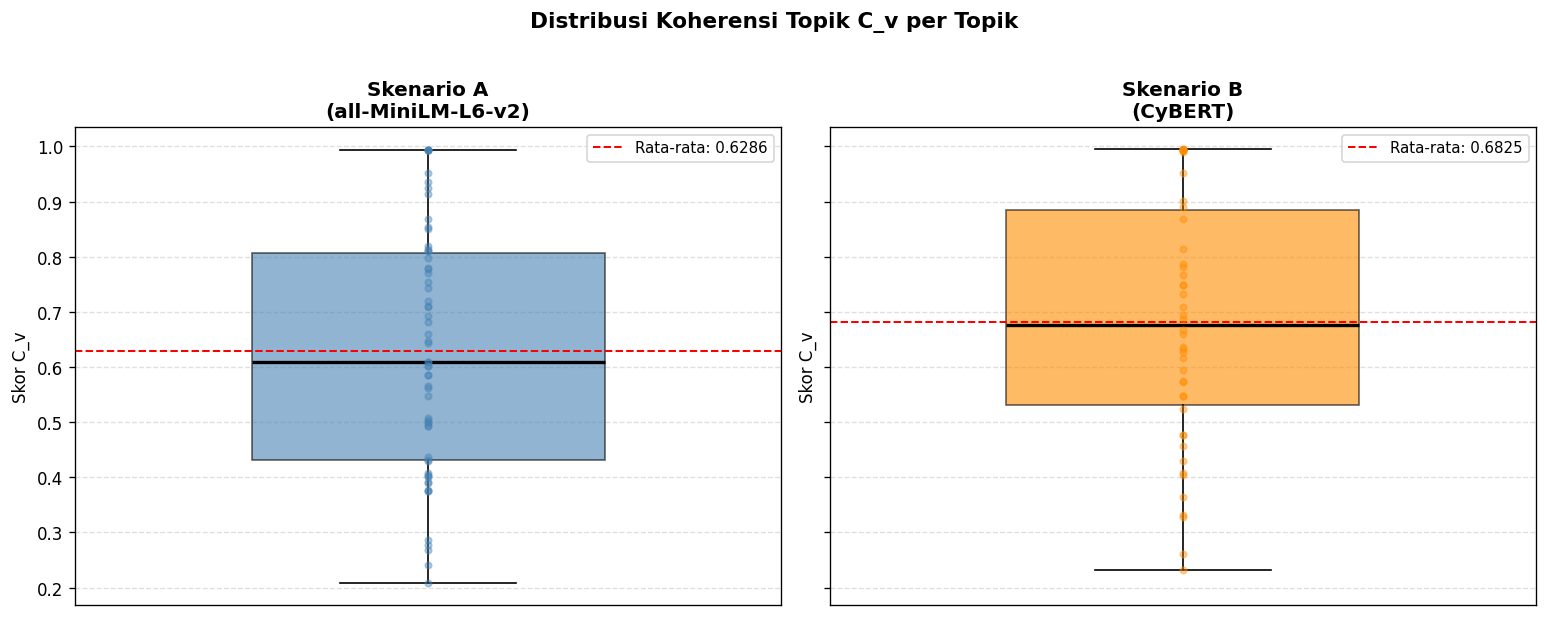

Visualisasi boxplot C_v disimpan.


In [14]:
# Memvisualisasikan distribusi skor C_v per topik menggunakan boxplot
# yang menampilkan nilai median, kuartil, dan sebaran data.
# Visualisasi ini memberikan gambaran yang lebih kaya daripada sekadar
# membandingkan nilai rata-rata.

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, skor, label, warna in zip(
    axes,
    [skor_cv_per_topik_A, skor_cv_per_topik_B],
    ["Skenario A\n(all-MiniLM-L6-v2)", "Skenario B\n(CyBERT)"],
    ["steelblue", "darkorange"]
):
    ax.boxplot(skor, patch_artist=True,
               boxprops=dict(facecolor=warna, alpha=0.6),
               medianprops=dict(color="black", linewidth=2),
               widths=0.5)
    ax.scatter([1] * len(skor), skor, alpha=0.4, s=15, color=warna, zorder=3)
    ax.axhline(np.mean(skor), color="red", linestyle="--",
               linewidth=1.2, label=f"Rata-rata: {np.mean(skor):.4f}")
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_ylabel("Skor C_v", fontsize=10)
    ax.set_xticks([])
    ax.legend(fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

fig.suptitle("Distribusi Koherensi Topik C_v per Topik",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_EVA / "boxplot_koherensi_cv.png", dpi=150, bbox_inches="tight")
plt.show()
print("Visualisasi boxplot C_v disimpan.")

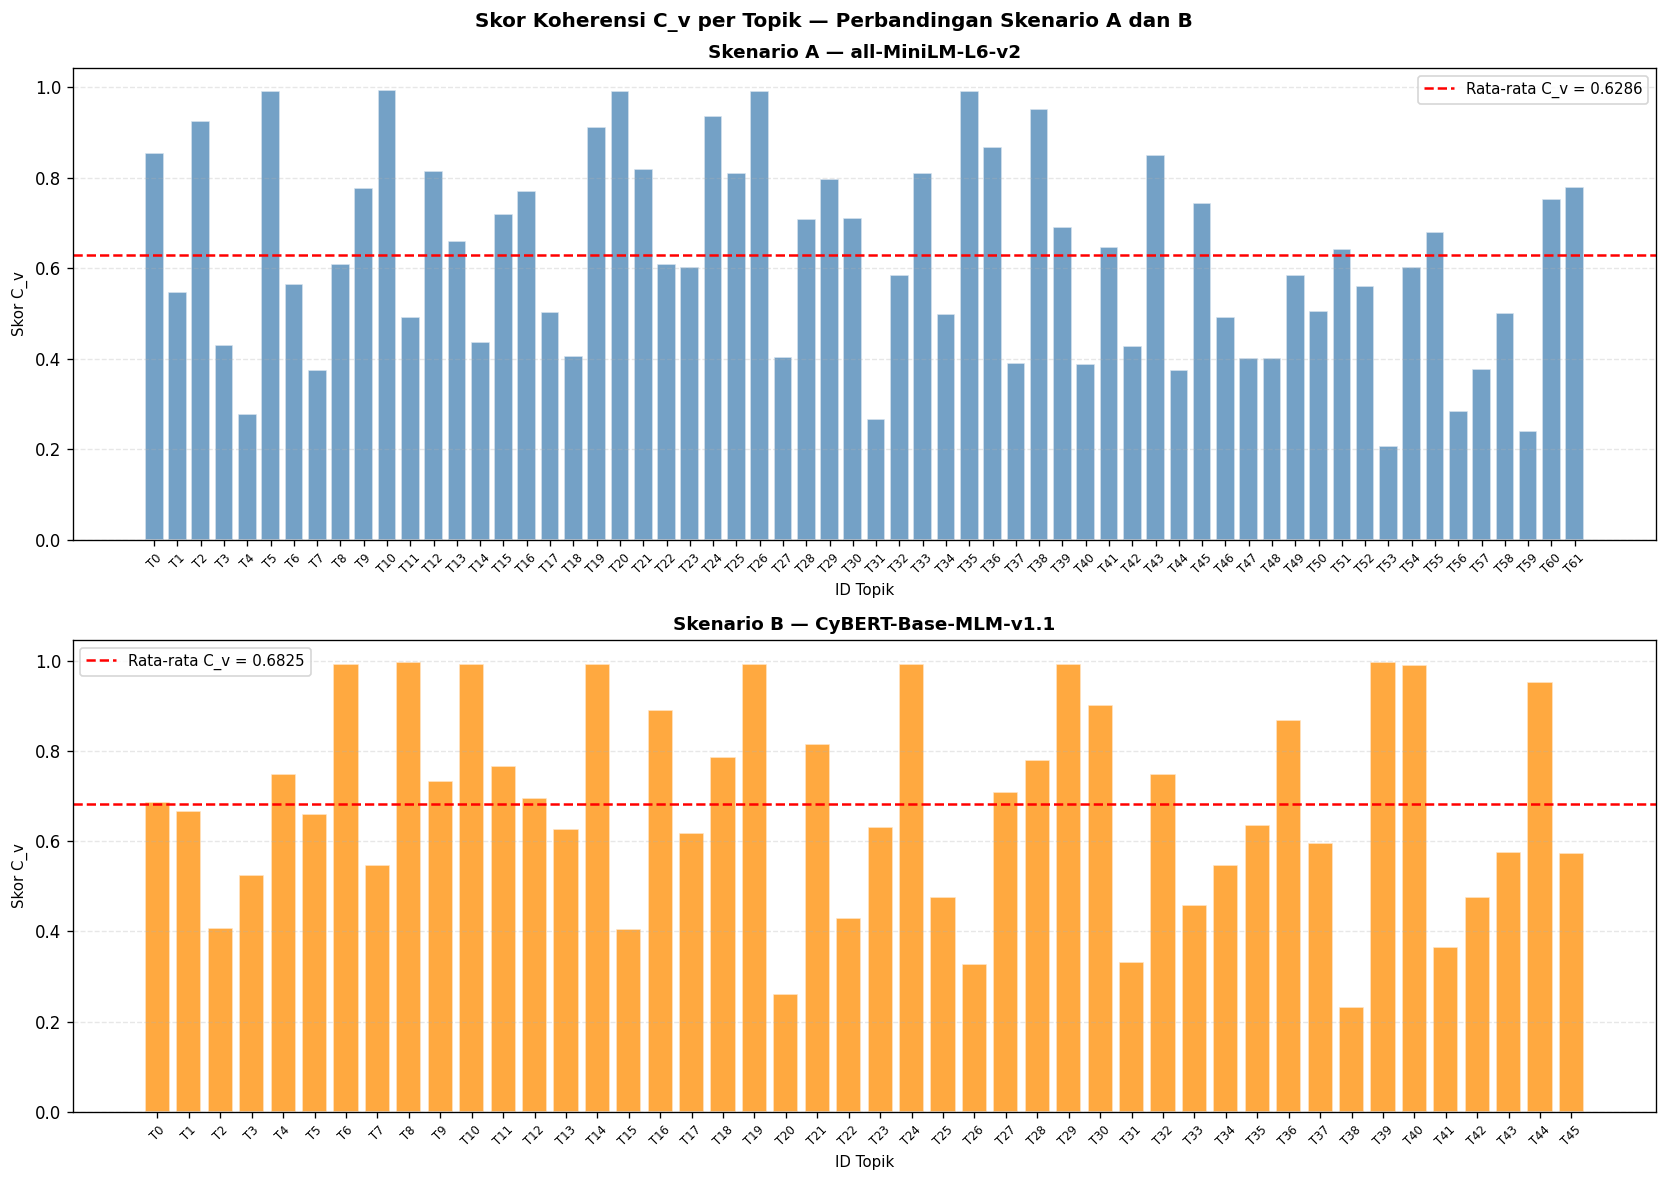

Visualisasi barchart C_v per topik disimpan.


In [15]:
# Memvisualisasikan skor C_v per topik dalam bentuk bar chart
# untuk melihat topik mana yang memiliki koherensi tinggi atau rendah
# di masing-masing skenario secara individual.

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

for ax, skor, label, warna, n_topik in zip(
    [ax1, ax2],
    [skor_cv_per_topik_A, skor_cv_per_topik_B],
    ["Skenario A — all-MiniLM-L6-v2", "Skenario B — CyBERT-Base-MLM-v1.1"],
    ["steelblue", "darkorange"],
    [RINGKASAN["skenario_A"]["jumlah_topik"], RINGKASAN["skenario_B"]["jumlah_topik"]]
):
    topik_labels = [f"T{i}" for i in range(len(skor))]
    bars = ax.bar(topik_labels, skor, color=warna, alpha=0.75, edgecolor="white")
    ax.axhline(np.mean(skor), color="red", linestyle="--",
               linewidth=1.5, label=f"Rata-rata C_v = {np.mean(skor):.4f}")
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_ylabel("Skor C_v", fontsize=9)
    ax.set_xlabel("ID Topik", fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.tick_params(axis="x", labelsize=7, rotation=45)

plt.suptitle("Skor Koherensi C_v per Topik — Perbandingan Skenario A dan B",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_EVA / "barchart_cv_per_topik.png", dpi=150, bbox_inches="tight")
plt.show()
print("Visualisasi barchart C_v per topik disimpan.")

---
## 4. Evaluasi Kuantitatif — Koefisien Siluet

Koefisien Siluet (*Silhouette Coefficient*) mengukur seberapa baik setiap dokumen ditempatkan dalam klasternya dibandingkan klaster terdekat lainnya. Nilai berkisar antara -1 hingga +1: nilai mendekati +1 menunjukkan dokumen berada jauh dari klaster tetangga (klasterisasi baik), nilai mendekati 0 menunjukkan dokumen berada di perbatasan antar klaster, dan nilai negatif menunjukkan dokumen mungkin salah klaster.

In [16]:
# Menyiapkan label klaster dan embedding yang akan digunakan
# untuk perhitungan Koefisien Siluet.
# Dokumen outlier (label -1) dikecualikan karena tidak termasuk klaster manapun
# dan akan mendistorsi nilai siluet jika disertakan.

label_A = df_A["topik_skenario_A"].values
label_B = df_B["topik_skenario_B"].values

# Filter hanya dokumen yang berhasil diklaster (label != -1)
mask_klaster_A = label_A != -1
mask_klaster_B = label_B != -1

emb_klaster_A = embeddings_A[mask_klaster_A]
lbl_klaster_A = label_A[mask_klaster_A]

emb_klaster_B = embeddings_B[mask_klaster_B]
lbl_klaster_B = label_B[mask_klaster_B]

print(f"Dokumen untuk siluet Skenario A : {len(emb_klaster_A)} ({mask_klaster_A.sum()/len(label_A)*100:.1f}% dari total)")
print(f"Dokumen untuk siluet Skenario B : {len(emb_klaster_B)} ({mask_klaster_B.sum()/len(label_B)*100:.1f}% dari total)")

Dokumen untuk siluet Skenario A : 2233 (64.5% dari total)
Dokumen untuk siluet Skenario B : 2890 (83.5% dari total)


In [17]:
# Menormalisasi embedding sebelum menghitung siluet.
# Normalisasi L2 dilakukan agar jarak kosinus antara vektor dapat
# diukur menggunakan jarak Euclidean, yang merupakan default scikit-learn.
# Tanpa normalisasi, perbedaan magnitudo vektor bisa mempengaruhi hasil.

emb_A_norm = normalize(emb_klaster_A, norm="l2")
emb_B_norm = normalize(emb_klaster_B, norm="l2")

print("Normalisasi L2 embedding selesai.")
print(f"  Embedding A ternormalisasi : shape={emb_A_norm.shape}")
print(f"  Embedding B ternormalisasi : shape={emb_B_norm.shape}")

Normalisasi L2 embedding selesai.
  Embedding A ternormalisasi : shape=(2233, 384)
  Embedding B ternormalisasi : shape=(2890, 768)


In [18]:
# Menghitung Koefisien Siluet untuk Skenario A.
# Parameter sample_size digunakan untuk mempercepat komputasi
# pada dataset besar — perhitungan dilakukan pada sampel acak
# yang cukup representatif (2.000 dokumen).

print("Menghitung Koefisien Siluet Skenario A...")
print("(Menggunakan sampel 2.000 dokumen untuk efisiensi komputasi)")

SAMPLE_SIZE = min(2000, len(emb_A_norm))

skor_siluet_A = silhouette_score(
    emb_A_norm,
    lbl_klaster_A,
    metric="euclidean",
    sample_size=SAMPLE_SIZE,
    random_state=42,
)

print()
print(f"[OK] Koefisien Siluet Skenario A : {skor_siluet_A:.4f}")

Menghitung Koefisien Siluet Skenario A...
(Menggunakan sampel 2.000 dokumen untuk efisiensi komputasi)

[OK] Koefisien Siluet Skenario A : 0.0283


In [19]:
# Menghitung Koefisien Siluet untuk Skenario B.
# Parameter sample_size dan random_state identik dengan Skenario A
# untuk memastikan konsistensi metodologi evaluasi.

print("Menghitung Koefisien Siluet Skenario B...")
print("(Menggunakan sampel 2.000 dokumen untuk efisiensi komputasi)")

SAMPLE_SIZE_B = min(2000, len(emb_B_norm))

skor_siluet_B = silhouette_score(
    emb_B_norm,
    lbl_klaster_B,
    metric="euclidean",
    sample_size=SAMPLE_SIZE_B,
    random_state=42,
)

print()
print(f"[OK] Koefisien Siluet Skenario B : {skor_siluet_B:.4f}")

Menghitung Koefisien Siluet Skenario B...
(Menggunakan sampel 2.000 dokumen untuk efisiensi komputasi)

[OK] Koefisien Siluet Skenario B : 0.0060


In [20]:
# Menampilkan perbandingan Koefisien Siluet antar kedua skenario.

print("=" * 60)
print(" PERBANDINGAN KOEFISIEN SILUET")
print("=" * 60)
print(f"  {'Metrik':<35} {'Skenario A':>10} {'Skenario B':>10}")
print(f"  {'-'*55}")
print(f"  {'Koefisien Siluet':<35} {skor_siluet_A:>10.4f} {skor_siluet_B:>10.4f}")
print(f"  {'Dokumen Terklaster':<35} {mask_klaster_A.sum():>10} {mask_klaster_B.sum():>10}")
print(f"  {'Dokumen Outlier':<35} {(~mask_klaster_A).sum():>10} {(~mask_klaster_B).sum():>10}")
print(f"  {'Persentase Noise':<35} {RINGKASAN['skenario_A']['persen_noise']:>9.1f}% {RINGKASAN['skenario_B']['persen_noise']:>9.1f}%")
print("=" * 60)

pemenang_sil = "Skenario A" if skor_siluet_A > skor_siluet_B else "Skenario B"
selisih_sil  = abs(skor_siluet_A - skor_siluet_B)
print(f"\n  Siluet lebih tinggi : {pemenang_sil} (selisih {selisih_sil:.4f})")

 PERBANDINGAN KOEFISIEN SILUET
  Metrik                              Skenario A Skenario B
  -------------------------------------------------------
  Koefisien Siluet                        0.0283     0.0060
  Dokumen Terklaster                        2233       2890
  Dokumen Outlier                           1228        571
  Persentase Noise                         35.5%      16.5%

  Siluet lebih tinggi : Skenario A (selisih 0.0224)


---
## 5. Ringkasan Evaluasi Kuantitatif

Menggabungkan seluruh metrik struktural ke dalam satu tabel ringkasan dan visualisasi radar untuk memudahkan interpretasi.

In [21]:
# Membuat tabel ringkasan evaluasi kuantitatif secara lengkap.
# Tabel ini menggabungkan semua metrik struktural yang telah dihitung
# dan dapat langsung dikutip pada bab hasil penelitian.

tabel_kuantitatif = pd.DataFrame({
    "Metrik": [
        "Model Embedding",
        "Jumlah Topik Terbentuk",
        "Dokumen Terklaster",
        "Dokumen Outlier (Noise)",
        "Persentase Noise (%)",
        "Koherensi Topik C_v (rata-rata)",
        "C_v Tertinggi",
        "C_v Terendah",
        "Std. Deviasi C_v",
        "Koefisien Siluet",
    ],
    "Skenario A": [
        "all-MiniLM-L6-v2",
        RINGKASAN["skenario_A"]["jumlah_topik"],
        RINGKASAN["skenario_A"]["dokumen_klaster"],
        RINGKASAN["skenario_A"]["dokumen_outlier"],
        f"{RINGKASAN['skenario_A']['persen_noise']:.1f}%",
        f"{skor_cv_A:.4f}",
        f"{max(skor_cv_per_topik_A):.4f}",
        f"{min(skor_cv_per_topik_A):.4f}",
        f"{np.std(skor_cv_per_topik_A):.4f}",
        f"{skor_siluet_A:.4f}",
    ],
    "Skenario B": [
        "CyBERT-Base-MLM-v1.1",
        RINGKASAN["skenario_B"]["jumlah_topik"],
        RINGKASAN["skenario_B"]["dokumen_klaster"],
        RINGKASAN["skenario_B"]["dokumen_outlier"],
        f"{RINGKASAN['skenario_B']['persen_noise']:.1f}%",
        f"{skor_cv_B:.4f}",
        f"{max(skor_cv_per_topik_B):.4f}",
        f"{min(skor_cv_per_topik_B):.4f}",
        f"{np.std(skor_cv_per_topik_B):.4f}",
        f"{skor_siluet_B:.4f}",
    ]
})

# Simpan tabel ke CSV
tabel_kuantitatif.to_csv(RESULTS_EVA / "tabel_evaluasi_kuantitatif.csv",
                          index=False, encoding="utf-8-sig")

print("Tabel Evaluasi Kuantitatif:")
print()
tabel_kuantitatif

Tabel Evaluasi Kuantitatif:



,Metrik,Skenario A,Skenario B
0,Model Embedding,all-MiniLM-L6-v2,CyBERT-Base-MLM-v1.1
1,Jumlah Topik Terbentuk,62,46
2,Dokumen Terklaster,2233,2890
3,Dokumen Outlier (Noise),1228,571
4,Persentase Noise (%),35.5%,16.5%
5,Koherensi Topik C_v (rata-rata),0.6286,0.6825
6,C_v Tertinggi,0.9933,0.9958
7,C_v Terendah,0.2078,0.2315
8,Std. Deviasi C_v,0.2171,0.2242
9,Koefisien Siluet,0.0283,0.0060


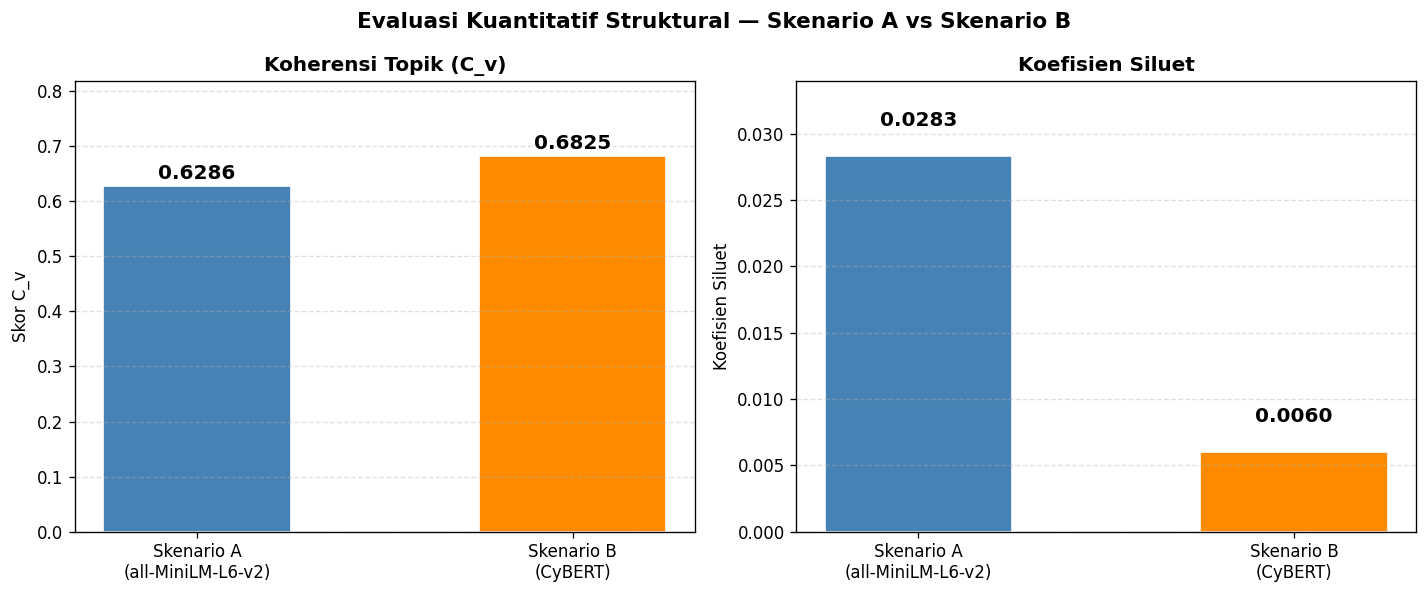

Visualisasi perbandingan metrik disimpan.


In [22]:
# Membuat visualisasi perbandingan dua metrik utama secara berdampingan:
# Koherensi C_v dan Koefisien Siluet, menggunakan grouped bar chart.
# Normalisasi ke skala 0-1 dilakukan agar kedua metrik dapat
# dibandingkan dalam satu sumbu yang sama.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Panel kiri: Koherensi C_v ---
ax1 = axes[0]
bars_cv = ax1.bar(
    ["Skenario A\n(all-MiniLM-L6-v2)", "Skenario B\n(CyBERT)"],
    [skor_cv_A, skor_cv_B],
    color=["steelblue", "darkorange"],
    width=0.5,
    edgecolor="white",
)
for bar, val in zip(bars_cv, [skor_cv_A, skor_cv_B]):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.005,
             f"{val:.4f}", ha="center", va="bottom", fontsize=12, fontweight="bold")
ax1.set_title("Koherensi Topik (C_v)", fontsize=12, fontweight="bold")
ax1.set_ylabel("Skor C_v", fontsize=10)
ax1.set_ylim(0, max(skor_cv_A, skor_cv_B) * 1.2)
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# --- Panel kanan: Koefisien Siluet ---
ax2 = axes[1]
bars_sil = ax2.bar(
    ["Skenario A\n(all-MiniLM-L6-v2)", "Skenario B\n(CyBERT)"],
    [skor_siluet_A, skor_siluet_B],
    color=["steelblue", "darkorange"],
    width=0.5,
    edgecolor="white",
)
for bar, val in zip(bars_sil, [skor_siluet_A, skor_siluet_B]):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.002,
             f"{val:.4f}", ha="center", va="bottom", fontsize=12, fontweight="bold")
ax2.set_title("Koefisien Siluet", fontsize=12, fontweight="bold")
ax2.set_ylabel("Koefisien Siluet", fontsize=10)
ax2.set_ylim(0, max(skor_siluet_A, skor_siluet_B) * 1.2)
ax2.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Evaluasi Kuantitatif Struktural — Skenario A vs Skenario B",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_EVA / "perbandingan_metrik_kuantitatif.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Visualisasi perbandingan metrik disimpan.")

---
## 6. Evaluasi Kualitatif — Persiapan Tinjauan Pakar

Evaluasi kualitatif semantik dilakukan dengan menyajikan daftar topik beserta kata-kata kunci representatifnya kepada pakar domain keamanan siber. Tahap ini menghasilkan dokumen referensi yang dapat digunakan sebagai bahan tinjauan pakar (*expert review*) untuk menilai relevansi dan kohesi semantik topik-topik yang terbentuk.

In [23]:
# Membangun tabel tinjauan pakar untuk Skenario A.
# Setiap baris merepresentasikan satu topik dengan ID, jumlah dokumen,
# kata kunci utama, dan dokumen representatif yang menjadi contoh
# isi dari topik tersebut.

def bangun_tabel_pakar(topic_model, df_hasil, kolom_topik: str, n_kata: int = 8) -> pd.DataFrame:
    """
    Membangun tabel lengkap untuk tinjauan pakar dari model BERTopic.
    """
    info = topic_model.get_topic_info()
    baris = []

    for _, baris_info in info[info["Topic"] != -1].iterrows():
        tid = baris_info["Topic"]
        jumlah = baris_info["Count"]
        nama = baris_info.get("Name", f"topik_{tid}")

        kata = topic_model.get_topic(tid)
        if not kata:
            continue

        kata_kunci_str = ", ".join([w for w, _ in kata[:n_kata]])
        skor_str       = ", ".join([f"{s:.3f}" for _, s in kata[:n_kata]])

        # Ambil contoh advisory dari topik ini
        contoh = df_hasil[df_hasil[kolom_topik] == tid]["advisory_id"].head(3).tolist()
        contoh_str = "; ".join(contoh)

        baris.append({
            "ID Topik"         : tid,
            "Nama Topik"       : nama,
            "Jumlah Dokumen"   : jumlah,
            "Kata Kunci Utama" : kata_kunci_str,
            "Skor c-TF-IDF"    : skor_str,
            "Contoh Advisory"  : contoh_str,
        })

    return pd.DataFrame(baris).sort_values("Jumlah Dokumen", ascending=False).reset_index(drop=True)


tabel_pakar_A = bangun_tabel_pakar(topic_model_A, df_A, "topik_skenario_A")
tabel_pakar_B = bangun_tabel_pakar(topic_model_B, df_B, "topik_skenario_B")

print(f"Tabel tinjauan pakar Skenario A : {len(tabel_pakar_A)} topik")
print(f"Tabel tinjauan pakar Skenario B : {len(tabel_pakar_B)} topik")

Tabel tinjauan pakar Skenario A : 62 topik
Tabel tinjauan pakar Skenario B : 46 topik


In [24]:
# Menampilkan 15 topik terbesar dari Skenario A untuk inspeksi.
# Tampilan ini menunjukkan struktur data yang akan diserahkan kepada pakar.

print("=== Topik Skenario A (15 Terbesar) ===")
tabel_pakar_A[["ID Topik", "Jumlah Dokumen", "Kata Kunci Utama", "Contoh Advisory"]].head(15)

=== Topik Skenario A (15 Terbesar) ===


,ID Topik,Jumlah Dokumen,Kata Kunci Utama,Contoh Advisory
0,0,249,"rockwell, automation, cisa, rockwell automatio...",ICSA-12-150-01; ICSA-13-011-03; ICSA-13-053-02A
1,1,124,"files, later version, parsing, open untrusted,...",ICSA-12-145-02; ICSA-15-111-02; ICSA-15-120-01
2,2,106,"hitachi, hitachi energy, energy, process contr...",ICSA-16-152-02; ICSA-19-178-01; ICSA-19-330-02
3,3,88,"affected, siemens, access, attacker, later ver...",ICSA-10-147-01; ICSA-16-308-02B; ICSA-17-243-02
4,4,82,"siemens, devices, cisa, security, defense, con...",ICSA-12-305-01; ICSA-16-334-02; ICSA-18-025-02B
5,5,75,"cisa, avoiding, email, social, social engineer...",ICSA-16-320-01; ICSA-19-029-02; ICSA-23-213-01
6,6,69,"android, siemens, security, industrial securit...",ICSA-16-140-02; ICSA-17-187-03F; ICSA-18-067-01
7,7,63,"ics cert, cert, nccic, cvss, 2017, assigned, i...",ICSA-17-026-02A; ICSA-17-045-02; ICSA-17-047-02
8,8,59,"ics cert, cert, nccic, ics, recommended practi...",ICSA-17-010-01A; ICSA-17-019-01A; ICSA-17-024-01
9,9,59,"wincc, siemens, tia portal, tia, cisa, portal,...",ICSA-11-244-01; ICSA-11-279-03A; ICSA-11-356-01


In [25]:
# Menampilkan 15 topik terbesar dari Skenario B untuk inspeksi.
# Bandingkan kata kunci yang muncul di sini dengan Skenario A
# untuk mendapatkan gambaran awal perbedaan semantik antar model.

print("=== Topik Skenario B (15 Terbesar) ===")
tabel_pakar_B[["ID Topik", "Jumlah Dokumen", "Kata Kunci Utama", "Contoh Advisory"]].head(15)

=== Topik Skenario B (15 Terbesar) ===


,ID Topik,Jumlah Dokumen,Kata Kunci Utama,Contoh Advisory
0,0,980,"cvss, cve, assigned, users, vulnerability, bas...",ICSA-12-213-01A; ICSA-13-095-02A; ICSA-15-169-01B
1,1,322,"cert, ics, cisa, recommended practices, ics ce...",ICSA-17-012-02; ICSA-17-031-02; ICSA-17-038-01
2,2,198,"cisa, ics, gov ics, exploitation, vulnerabilit...",ICSA-13-018-01; ICSA-17-220-02; ICSMA-18-137-02
3,3,103,"affected, application, siemens, attacker, acce...",ICSA-12-158-01; ICSA-15-020-02; ICSA-16-322-02
4,4,91,"update, later version, later, version update, ...",ICSA-14-329-02D; ICSA-15-099-01E; ICSA-15-335-03
5,5,86,"update, later version, version update, siemens...",ICSA-17-045-03; ICSA-17-187-03F; ICSA-17-318-02A
6,6,84,"cisa, avoiding, social, social engineering, em...",ICSA-11-017-01; ICSA-11-018-02; ICSA-11-074-01
7,7,72,"siemens, cisa, devices, security, recommends, ...",ICSA-13-042-01; ICSA-15-265-02; ICSA-19-344-04
8,8,70,"cisa, ics, avoiding, email, social, social eng...",ICSA-19-029-02; ICSMA-22-244-01; ICSA-23-243-01
9,9,55,"siemens, devices, cisa, security, industrial, ...",ICSA-17-243-01; ICSA-19-085-01; ICSA-19-344-01


In [26]:
# Menyimpan tabel tinjauan pakar ke file CSV.
# File ini yang akan dikirimkan kepada pakar domain keamanan siber
# sebagai bahan evaluasi kualitatif pada penelitian.

tabel_pakar_A.to_csv(RESULTS_EVA / "tabel_tinjauan_pakar_skenario_A.csv",
                      index=False, encoding="utf-8-sig")
tabel_pakar_B.to_csv(RESULTS_EVA / "tabel_tinjauan_pakar_skenario_B.csv",
                      index=False, encoding="utf-8-sig")

print("Tabel tinjauan pakar berhasil disimpan:")
print(f"  {RESULTS_EVA / 'tabel_tinjauan_pakar_skenario_A.csv'}")
print(f"  {RESULTS_EVA / 'tabel_tinjauan_pakar_skenario_B.csv'}")
print()
print("File CSV ini siap digunakan sebagai instrumen evaluasi kualitatif")
print("oleh pakar domain keamanan siber (ICS/SCADA security).")

Tabel tinjauan pakar berhasil disimpan:
  /Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier/results/evaluasi/tabel_tinjauan_pakar_skenario_A.csv
  /Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier/results/evaluasi/tabel_tinjauan_pakar_skenario_B.csv

File CSV ini siap digunakan sebagai instrumen evaluasi kualitatif
oleh pakar domain keamanan siber (ICS/SCADA security).


---
## 7. Analisis Distribusi Topik & Noise

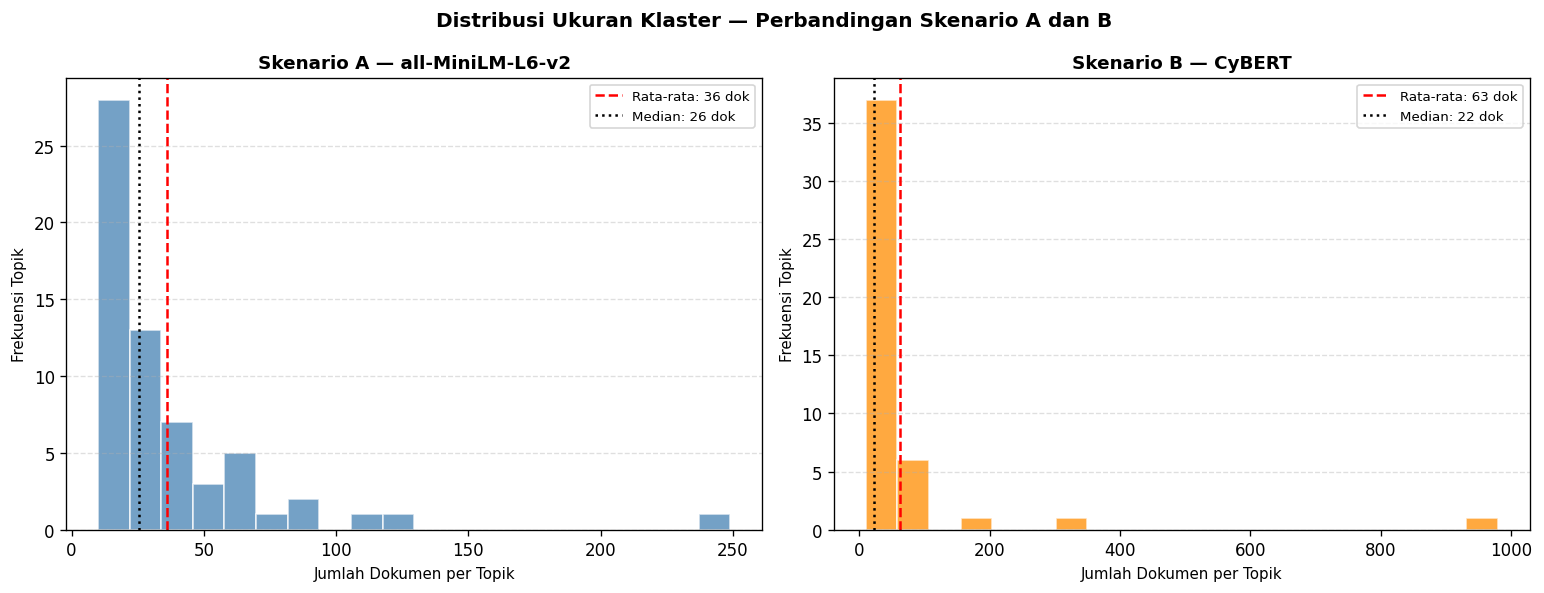

Visualisasi distribusi klaster disimpan.


In [27]:
# Membandingkan distribusi ukuran klaster antara kedua skenario
# menggunakan visualisasi histogram.
# Distribusi yang lebih merata dan lebih sedikit noise mengindikasikan
# model embedding yang menghasilkan representasi lebih terstruktur.

ukuran_klaster_A = tabel_pakar_A["Jumlah Dokumen"].values
ukuran_klaster_B = tabel_pakar_B["Jumlah Dokumen"].values

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for ax, ukuran, label, warna in zip(
    axes,
    [ukuran_klaster_A, ukuran_klaster_B],
    ["Skenario A — all-MiniLM-L6-v2", "Skenario B — CyBERT"],
    ["steelblue", "darkorange"]
):
    ax.hist(ukuran, bins=20, color=warna, alpha=0.75, edgecolor="white")
    ax.axvline(np.mean(ukuran), color="red", linestyle="--",
               linewidth=1.5, label=f"Rata-rata: {np.mean(ukuran):.0f} dok")
    ax.axvline(np.median(ukuran), color="black", linestyle=":",
               linewidth=1.5, label=f"Median: {np.median(ukuran):.0f} dok")
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("Jumlah Dokumen per Topik", fontsize=9)
    ax.set_ylabel("Frekuensi Topik", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Distribusi Ukuran Klaster — Perbandingan Skenario A dan B",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_EVA / "distribusi_ukuran_klaster.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Visualisasi distribusi klaster disimpan.")

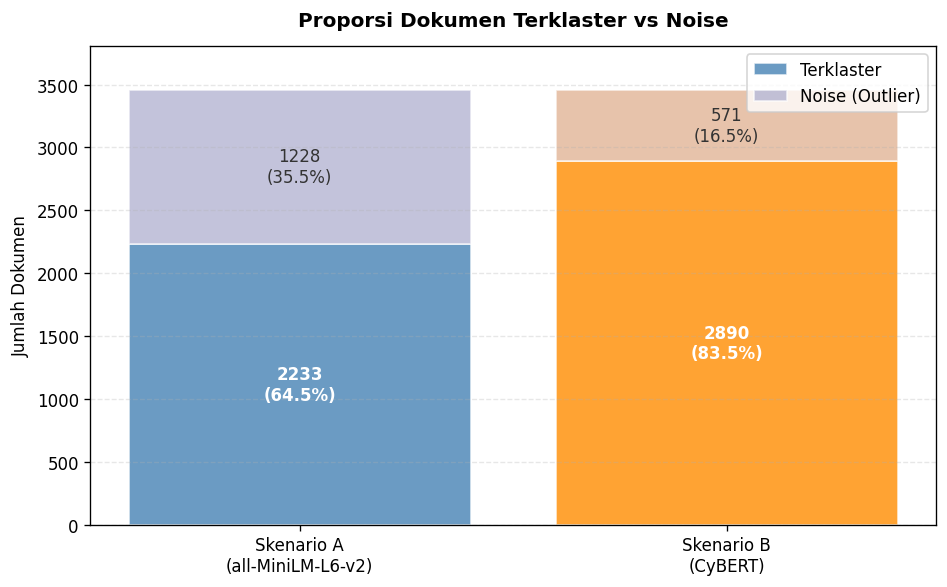

Visualisasi proporsi klaster vs noise disimpan.


In [28]:
# Membuat visualisasi perbandingan noise vs terklaster dalam bentuk
# stacked bar chart untuk menggambarkan efisiensi klasterisasi
# dari masing-masing model embedding.

fig, ax = plt.subplots(figsize=(8, 5))

skenario_labels = ["Skenario A\n(all-MiniLM-L6-v2)", "Skenario B\n(CyBERT)"]
dok_klaster = [RINGKASAN["skenario_A"]["dokumen_klaster"],
               RINGKASAN["skenario_B"]["dokumen_klaster"]]
dok_noise   = [RINGKASAN["skenario_A"]["dokumen_outlier"],
               RINGKASAN["skenario_B"]["dokumen_outlier"]]

bar_klaster = ax.bar(skenario_labels, dok_klaster,
                     color=["steelblue", "darkorange"], alpha=0.8,
                     label="Terklaster", edgecolor="white")
bar_noise   = ax.bar(skenario_labels, dok_noise,
                     bottom=dok_klaster, color=["#aaaacc", "#ddaa88"],
                     alpha=0.7, label="Noise (Outlier)", edgecolor="white")

# Tambahkan label persentase
total = 3461
for i, (k, n) in enumerate(zip(dok_klaster, dok_noise)):
    ax.text(i, k / 2, f"{k}\n({k/total*100:.1f}%)",
            ha="center", va="center", fontsize=10, fontweight="bold", color="white")
    ax.text(i, k + n / 2, f"{n}\n({n/total*100:.1f}%)",
            ha="center", va="center", fontsize=10, color="#333333")

ax.set_title("Proporsi Dokumen Terklaster vs Noise",
             fontsize=12, fontweight="bold", pad=12)
ax.set_ylabel("Jumlah Dokumen", fontsize=10)
ax.set_ylim(0, total * 1.1)
ax.legend(fontsize=10, loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_EVA / "proporsi_klaster_vs_noise.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Visualisasi proporsi klaster vs noise disimpan.")

---
## 8. Analisis dan Sintesis Hasil Evaluasi

In [29]:
# Menyusun tabel sintesis akhir yang menggabungkan semua dimensi evaluasi.
# Tabel ini dirancang agar dapat langsung digunakan pada bab
# pembahasan hasil penelitian dalam laporan skripsi.
#
# Arah perbandingan:
#   C_v        → lebih tinggi lebih baik (koherensi semantik)
#   Siluet     → lebih tinggi lebih baik (separasi klaster)
#   Noise      → lebih rendah lebih baik (efisiensi klasterisasi)
#   Jml Topik  → bergantung konteks (lebih sedikit bisa lebih bermakna)

def tentukan_unggul(val_A, val_B, lebih_tinggi_lebih_baik=True):
    if lebih_tinggi_lebih_baik:
        return "A" if val_A > val_B else ("B" if val_B > val_A else "Seimbang")
    else:
        return "A" if val_A < val_B else ("B" if val_B < val_A else "Seimbang")


sintesis = pd.DataFrame({
    "Dimensi Evaluasi": [
        "Koherensi Topik C_v",
        "Koefisien Siluet",
        "Persentase Noise (%)",
        "Jumlah Topik Terbentuk",
        "Dokumen Berhasil Diklaster",
    ],
    "Arah Optimal": [
        "Lebih tinggi ↑",
        "Lebih tinggi ↑",
        "Lebih rendah ↓",
        "Kontekstual",
        "Lebih banyak ↑",
    ],
    "Skenario A": [
        f"{skor_cv_A:.4f}",
        f"{skor_siluet_A:.4f}",
        f"{RINGKASAN['skenario_A']['persen_noise']:.1f}%",
        str(RINGKASAN["skenario_A"]["jumlah_topik"]),
        str(RINGKASAN["skenario_A"]["dokumen_klaster"]),
    ],
    "Skenario B": [
        f"{skor_cv_B:.4f}",
        f"{skor_siluet_B:.4f}",
        f"{RINGKASAN['skenario_B']['persen_noise']:.1f}%",
        str(RINGKASAN["skenario_B"]["jumlah_topik"]),
        str(RINGKASAN["skenario_B"]["dokumen_klaster"]),
    ],
    "Skenario Unggul": [
        tentukan_unggul(skor_cv_A, skor_cv_B, lebih_tinggi_lebih_baik=True),
        tentukan_unggul(skor_siluet_A, skor_siluet_B, lebih_tinggi_lebih_baik=True),
        tentukan_unggul(
            RINGKASAN["skenario_A"]["persen_noise"],
            RINGKASAN["skenario_B"]["persen_noise"],
            lebih_tinggi_lebih_baik=False
        ),
        "Kontekstual",
        tentukan_unggul(
            RINGKASAN["skenario_A"]["dokumen_klaster"],
            RINGKASAN["skenario_B"]["dokumen_klaster"],
            lebih_tinggi_lebih_baik=True
        ),
    ]
})

sintesis.to_csv(RESULTS_EVA / "tabel_sintesis_evaluasi.csv",
                index=False, encoding="utf-8-sig")

print("Tabel Sintesis Evaluasi Akhir:")
print()
sintesis

Tabel Sintesis Evaluasi Akhir:



,Dimensi Evaluasi,Arah Optimal,Skenario A,Skenario B,Skenario Unggul
0,Koherensi Topik C_v,Lebih tinggi ↑,0.6286,0.6825,B
1,Koefisien Siluet,Lebih tinggi ↑,0.0283,0.0060,A
2,Persentase Noise (%),Lebih rendah ↓,35.5%,16.5%,B
3,Jumlah Topik Terbentuk,Kontekstual,62,46,Kontekstual
4,Dokumen Berhasil Diklaster,Lebih banyak ↑,2233,2890,B


In [30]:
# Menampilkan ringkasan temuan evaluasi secara naratif.
# Temuan ini dapat digunakan sebagai dasar penulisan bab pembahasan.

print("=" * 65)
print(" SINTESIS HASIL EVALUASI")
print("=" * 65)
print()
print(" SKENARIO A — all-MiniLM-L6-v2")
print(f"   Topik terbentuk     : {RINGKASAN['skenario_A']['jumlah_topik']}")
print(f"   Koherensi C_v       : {skor_cv_A:.4f}")
print(f"   Koefisien Siluet    : {skor_siluet_A:.4f}")
print(f"   Tingkat Noise       : {RINGKASAN['skenario_A']['persen_noise']}%")
print()
print(" SKENARIO B — CyBERT-Base-MLM-v1.1")
print(f"   Topik terbentuk     : {RINGKASAN['skenario_B']['jumlah_topik']}")
print(f"   Koherensi C_v       : {skor_cv_B:.4f}")
print(f"   Koefisien Siluet    : {skor_siluet_B:.4f}")
print(f"   Tingkat Noise       : {RINGKASAN['skenario_B']['persen_noise']}%")
print()
print("-" * 65)
print(" TEMUAN KUANTITATIF")
print(f"   C_v lebih baik      : {pemenang_cv} (selisih {selisih_cv:.4f})")
print(f"   Siluet lebih baik   : {pemenang_sil} (selisih {selisih_sil:.4f})")
pemenang_noise = "Skenario B" if RINGKASAN["skenario_B"]["persen_noise"] < RINGKASAN["skenario_A"]["persen_noise"] else "Skenario A"
print(f"   Noise lebih rendah  : {pemenang_noise}")
print()
print(" CATATAN")
print("   Evaluasi kualitatif (tinjauan pakar) diperlukan untuk")
print("   menilai relevansi semantik topik-topik yang terbentuk.")
print("   File tabel tinjauan pakar telah disimpan di folder evaluasi.")
print("=" * 65)

 SINTESIS HASIL EVALUASI

 SKENARIO A — all-MiniLM-L6-v2
   Topik terbentuk     : 62
   Koherensi C_v       : 0.6286
   Koefisien Siluet    : 0.0283
   Tingkat Noise       : 35.5%

 SKENARIO B — CyBERT-Base-MLM-v1.1
   Topik terbentuk     : 46
   Koherensi C_v       : 0.6825
   Koefisien Siluet    : 0.0060
   Tingkat Noise       : 16.5%

-----------------------------------------------------------------
 TEMUAN KUANTITATIF
   C_v lebih baik      : Skenario B (selisih 0.0539)
   Siluet lebih baik   : Skenario A (selisih 0.0224)
   Noise lebih rendah  : Skenario B

 CATATAN
   Evaluasi kualitatif (tinjauan pakar) diperlukan untuk
   menilai relevansi semantik topik-topik yang terbentuk.
   File tabel tinjauan pakar telah disimpan di folder evaluasi.


In [31]:
# Menampilkan daftar seluruh file hasil evaluasi yang telah dihasilkan
# pada notebook ini.

print("File hasil evaluasi yang tersimpan di folder:")
print(f"  {RESULTS_EVA}")
print()

for f in sorted(RESULTS_EVA.iterdir()):
    ukuran = f.stat().st_size / 1024
    print(f"  {f.name:<50} {ukuran:>8.1f} KB")

print()
print("Evaluasi selesai. Semua file siap untuk lampiran laporan skripsi.")

File hasil evaluasi yang tersimpan di folder:
  /Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier/results/evaluasi

  barchart_cv_per_topik.png                             108.3 KB
  boxplot_koherensi_cv.png                               61.9 KB
  distribusi_ukuran_klaster.png                          63.4 KB
  perbandingan_metrik_kuantitatif.png                    66.1 KB
  proporsi_klaster_vs_noise.png                          54.9 KB
  tabel_evaluasi_kuantitatif.csv                          0.4 KB
  tabel_sintesis_evaluasi.csv                             0.3 KB
  tabel_tinjauan_pakar_skenario_A.csv                    14.0 KB
  tabel_tinjauan_pakar_skenario_B.csv                    10.8 KB
  topics_over_time_skenario_A.html                     4750.3 KB
  topics_over_time_skenario_B.html                     4750.9 KB

Evaluasi selesai. Semua file siap untuk lampiran laporan skripsi.


Analisis Topik 0 (Boilerplate/Generik) & Topic Diversity

In [32]:
# In [30]:
# Mengevaluasi Topik 0 sebagai 'Generic Administrative Topic' dan menghitung Diversity
import numpy as np

print("=== ANALISIS TOPIK GENERIK & DIVERSITY ===")
# Analisis Skenario A
topik_0_cv_A = skor_cv_per_topik_A[0]
topik_lain_cv_A = np.mean(skor_cv_per_topik_A[1:])
print(f"Skenario A - C_v Topik 0 (Generic) : {topik_0_cv_A:.4f}")
print(f"Skenario A - C_v rata-rata topik lain: {topik_lain_cv_A:.4f}")

# Analisis Skenario B
topik_0_cv_B = skor_cv_per_topik_B[0]
topik_lain_cv_B = np.mean(skor_cv_per_topik_B[1:])
print(f"Skenario B - C_v Topik 0 (Generic) : {topik_0_cv_B:.4f}")
print(f"Skenario B - C_v rata-rata topik lain: {topik_lain_cv_B:.4f}")

# Menghitung Topic Diversity (Persentase kata unik di seluruh topik)
def hitung_diversity(kata_kunci_list):
    semua_kata = []
    for kata_topik in kata_kunci_list:
        semua_kata.extend(kata_topik)
    kata_unik = set(semua_kata)
    return len(kata_unik) / len(semua_kata) if semua_kata else 0

div_A = hitung_diversity(kata_kunci_A)
div_B = hitung_diversity(kata_kunci_B)
print(f"\nTopic Diversity Skenario A: {div_A:.4f} ({div_A*100:.1f}% kata unik)")
print(f"Topic Diversity Skenario B: {div_B:.4f} ({div_B*100:.1f}% kata unik)")

=== ANALISIS TOPIK GENERIK & DIVERSITY ===
Skenario A - C_v Topik 0 (Generic) : 0.8548
Skenario A - C_v rata-rata topik lain: 0.6249
Skenario B - C_v Topik 0 (Generic) : 0.6874
Skenario B - C_v rata-rata topik lain: 0.6824

Topic Diversity Skenario A: 0.3295 (33.0% kata unik)
Topic Diversity Skenario B: 0.2787 (27.9% kata unik)


In [33]:
# In [31]:
# Membuat visualisasi tren topik per tahun untuk Skenario A (all-MiniLM-L6-v2)

# 1. Definisikan variabel 'dokumen' dari dataframe yang sudah diload di Notebook 04
dokumen = df_data['teks_bersih'].tolist()

# 2. Mengekstrak tahun dari kolom release_date
df_data['tahun'] = pd.to_datetime(df_data['release_date']).dt.year

# 3. Menghitung Topics Over Time
topics_over_time_A = topic_model_A.topics_over_time(
    dokumen, 
    df_data['tahun'].tolist(), 
    nr_bins=len(df_data['tahun'].unique())
)

# 4. Visualisasi interaktif
fig_tot = topic_model_A.visualize_topics_over_time(topics_over_time_A, top_n_topics=10)
path_tot = RESULTS_EVA / "topics_over_time_skenario_A.html"
fig_tot.write_html(str(path_tot))
print(f"Visualisasi Topics Over Time disimpan di: {path_tot}")
fig_tot.show()

16it [00:03,  5.19it/s]

Visualisasi Topics Over Time disimpan di: /Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier/results/evaluasi/topics_over_time_skenario_A.html


In [34]:
# In [32]:
# Membuat visualisasi tren topik per tahun untuk Skenario B (CyBERT)

# 1. Definisikan variabel 'dokumen' dari dataframe yang sudah diload di Notebook 04
dokumen = df_data['teks_bersih'].tolist()

# 2. Mengekstrak tahun dari kolom release_date
df_data['tahun'] = pd.to_datetime(df_data['release_date']).dt.year

# 3. Menghitung Topics Over Time
topics_over_time_B = topic_model_B.topics_over_time(
    dokumen, 
    df_data['tahun'].tolist(), 
    nr_bins=len(df_data['tahun'].unique())
)

# 4. Visualisasi interaktif
fig_tot = topic_model_B.visualize_topics_over_time(topics_over_time_B, top_n_topics=10)
path_tot = RESULTS_EVA / "topics_over_time_skenario_B.html"
fig_tot.write_html(str(path_tot))
print(f"Visualisasi Topics Over Time disimpan di: {path_tot}")
fig_tot.show()

16it [00:03,  5.19it/s]

Visualisasi Topics Over Time disimpan di: /Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier/results/evaluasi/topics_over_time_skenario_B.html


=== Word Cloud Skenario A (15 Topik Terbesar) ===


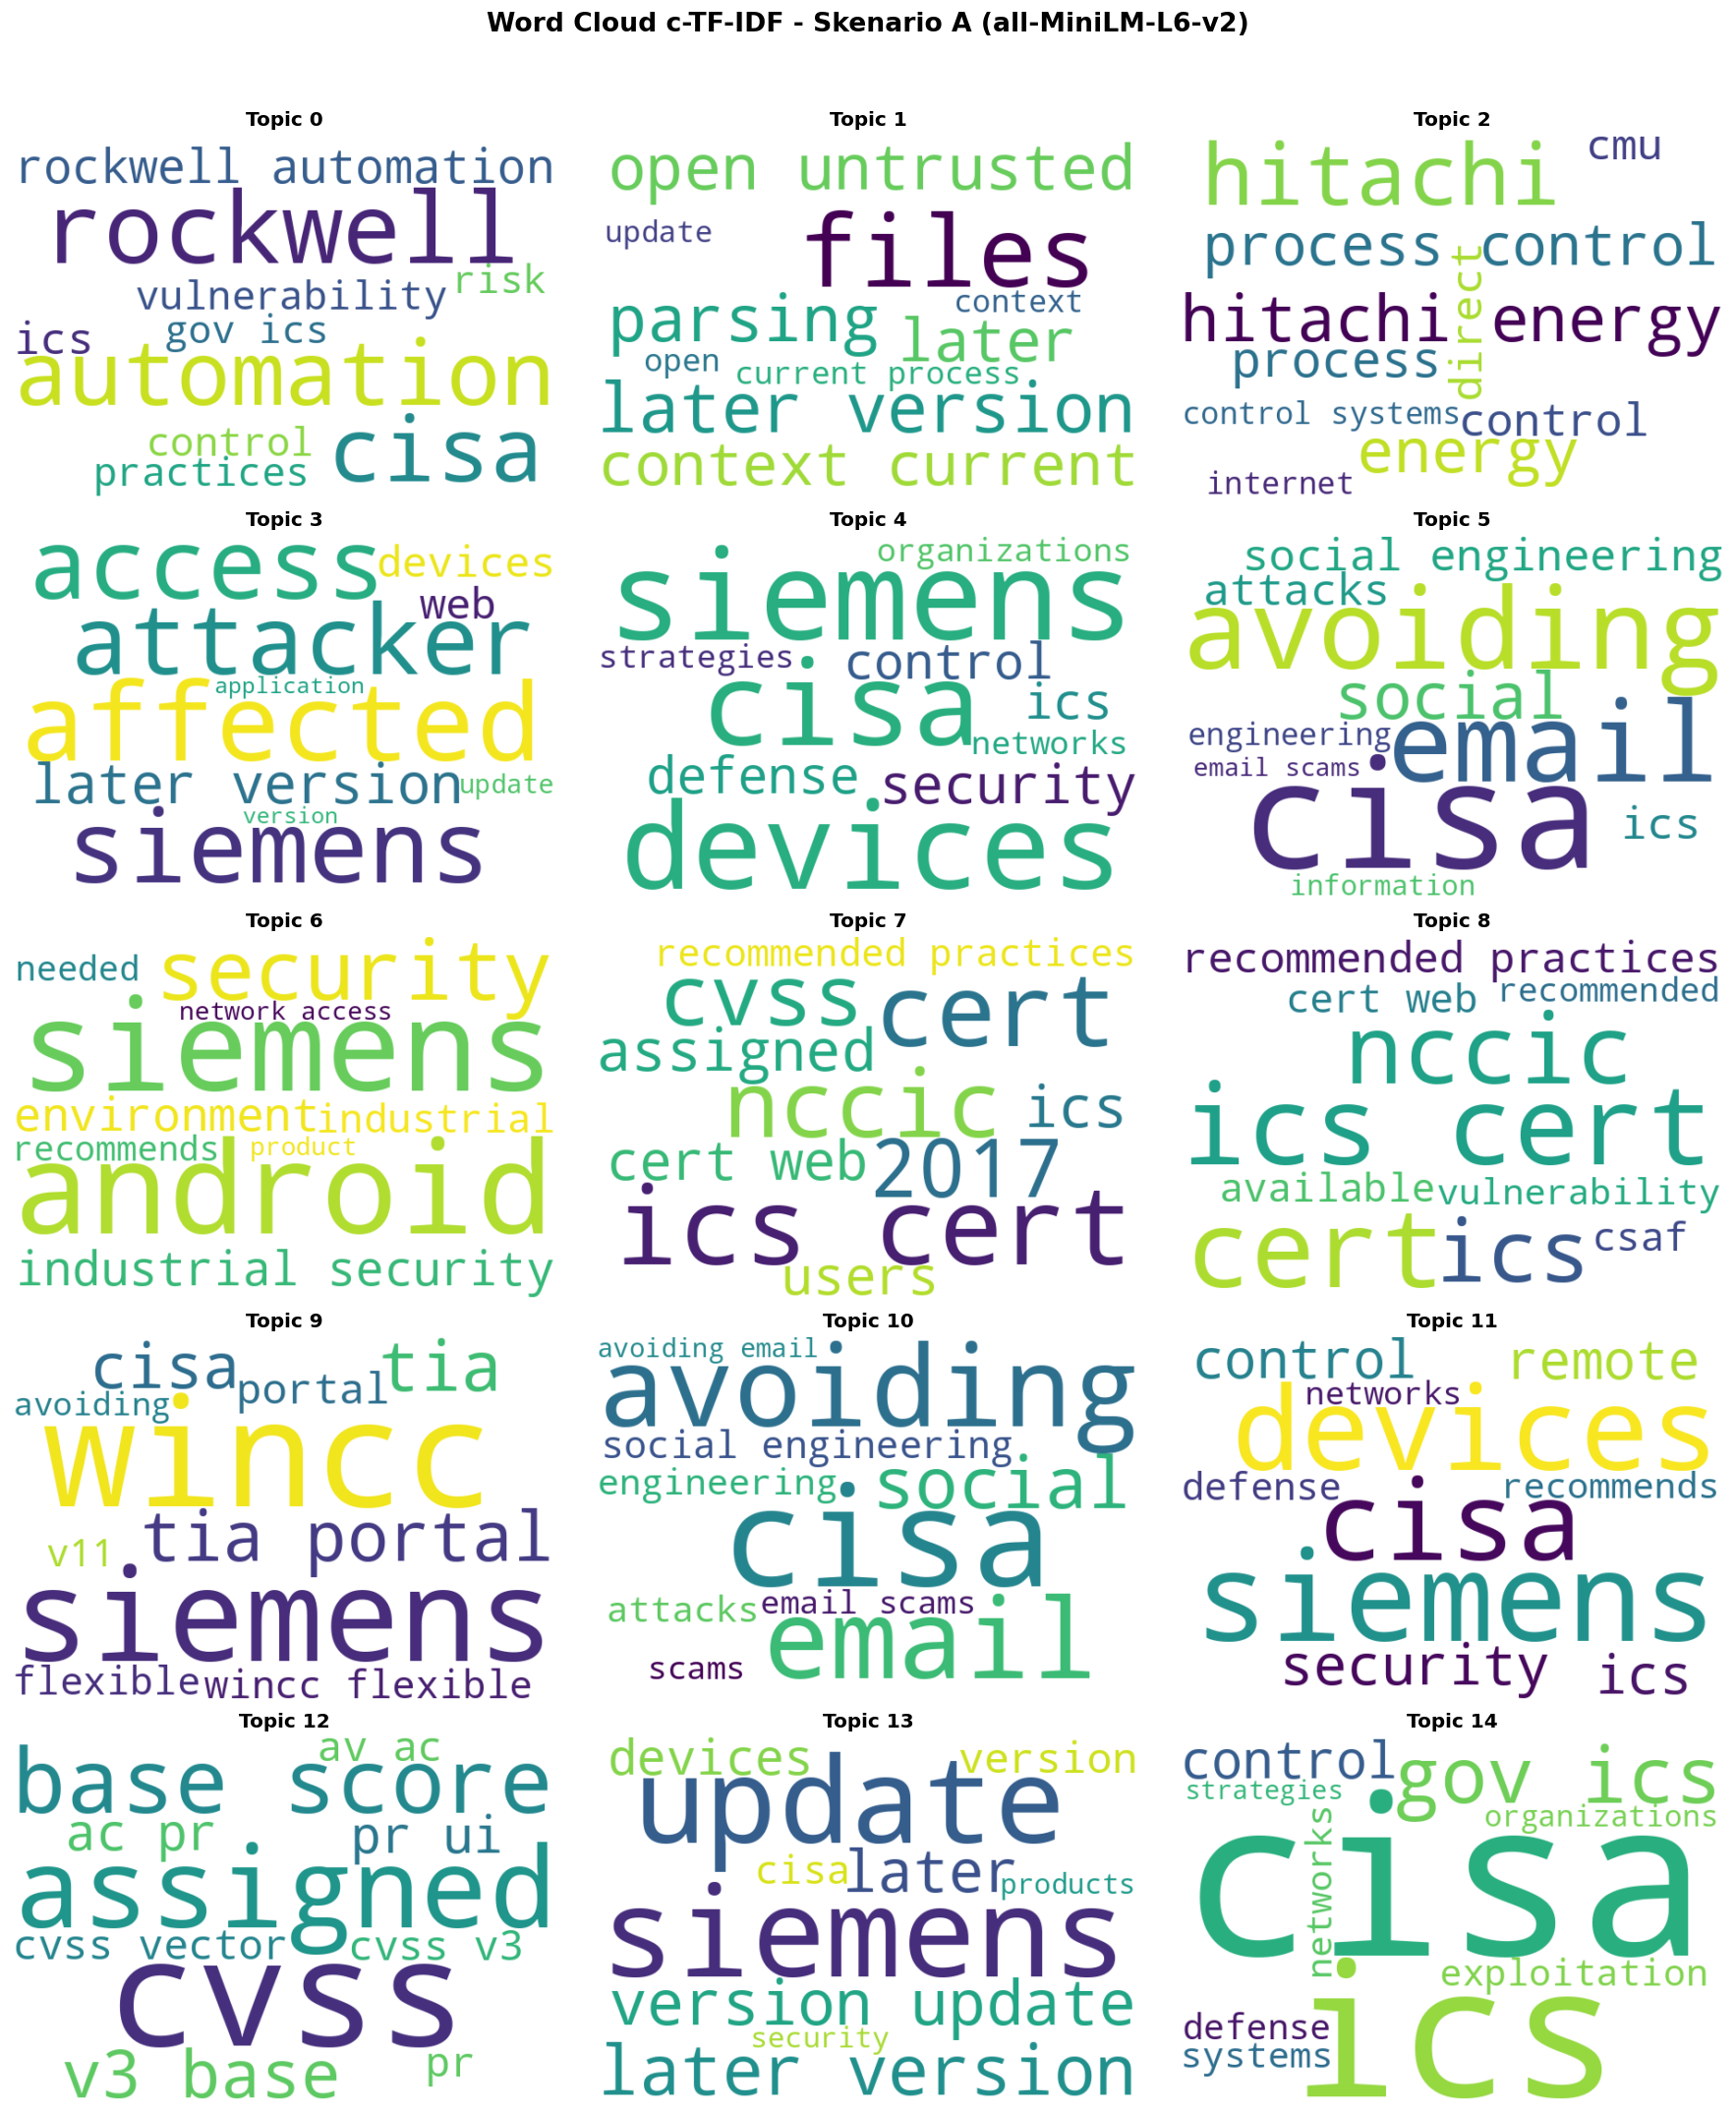

=== Word Cloud Skenario B (15 Topik Terbesar) ===


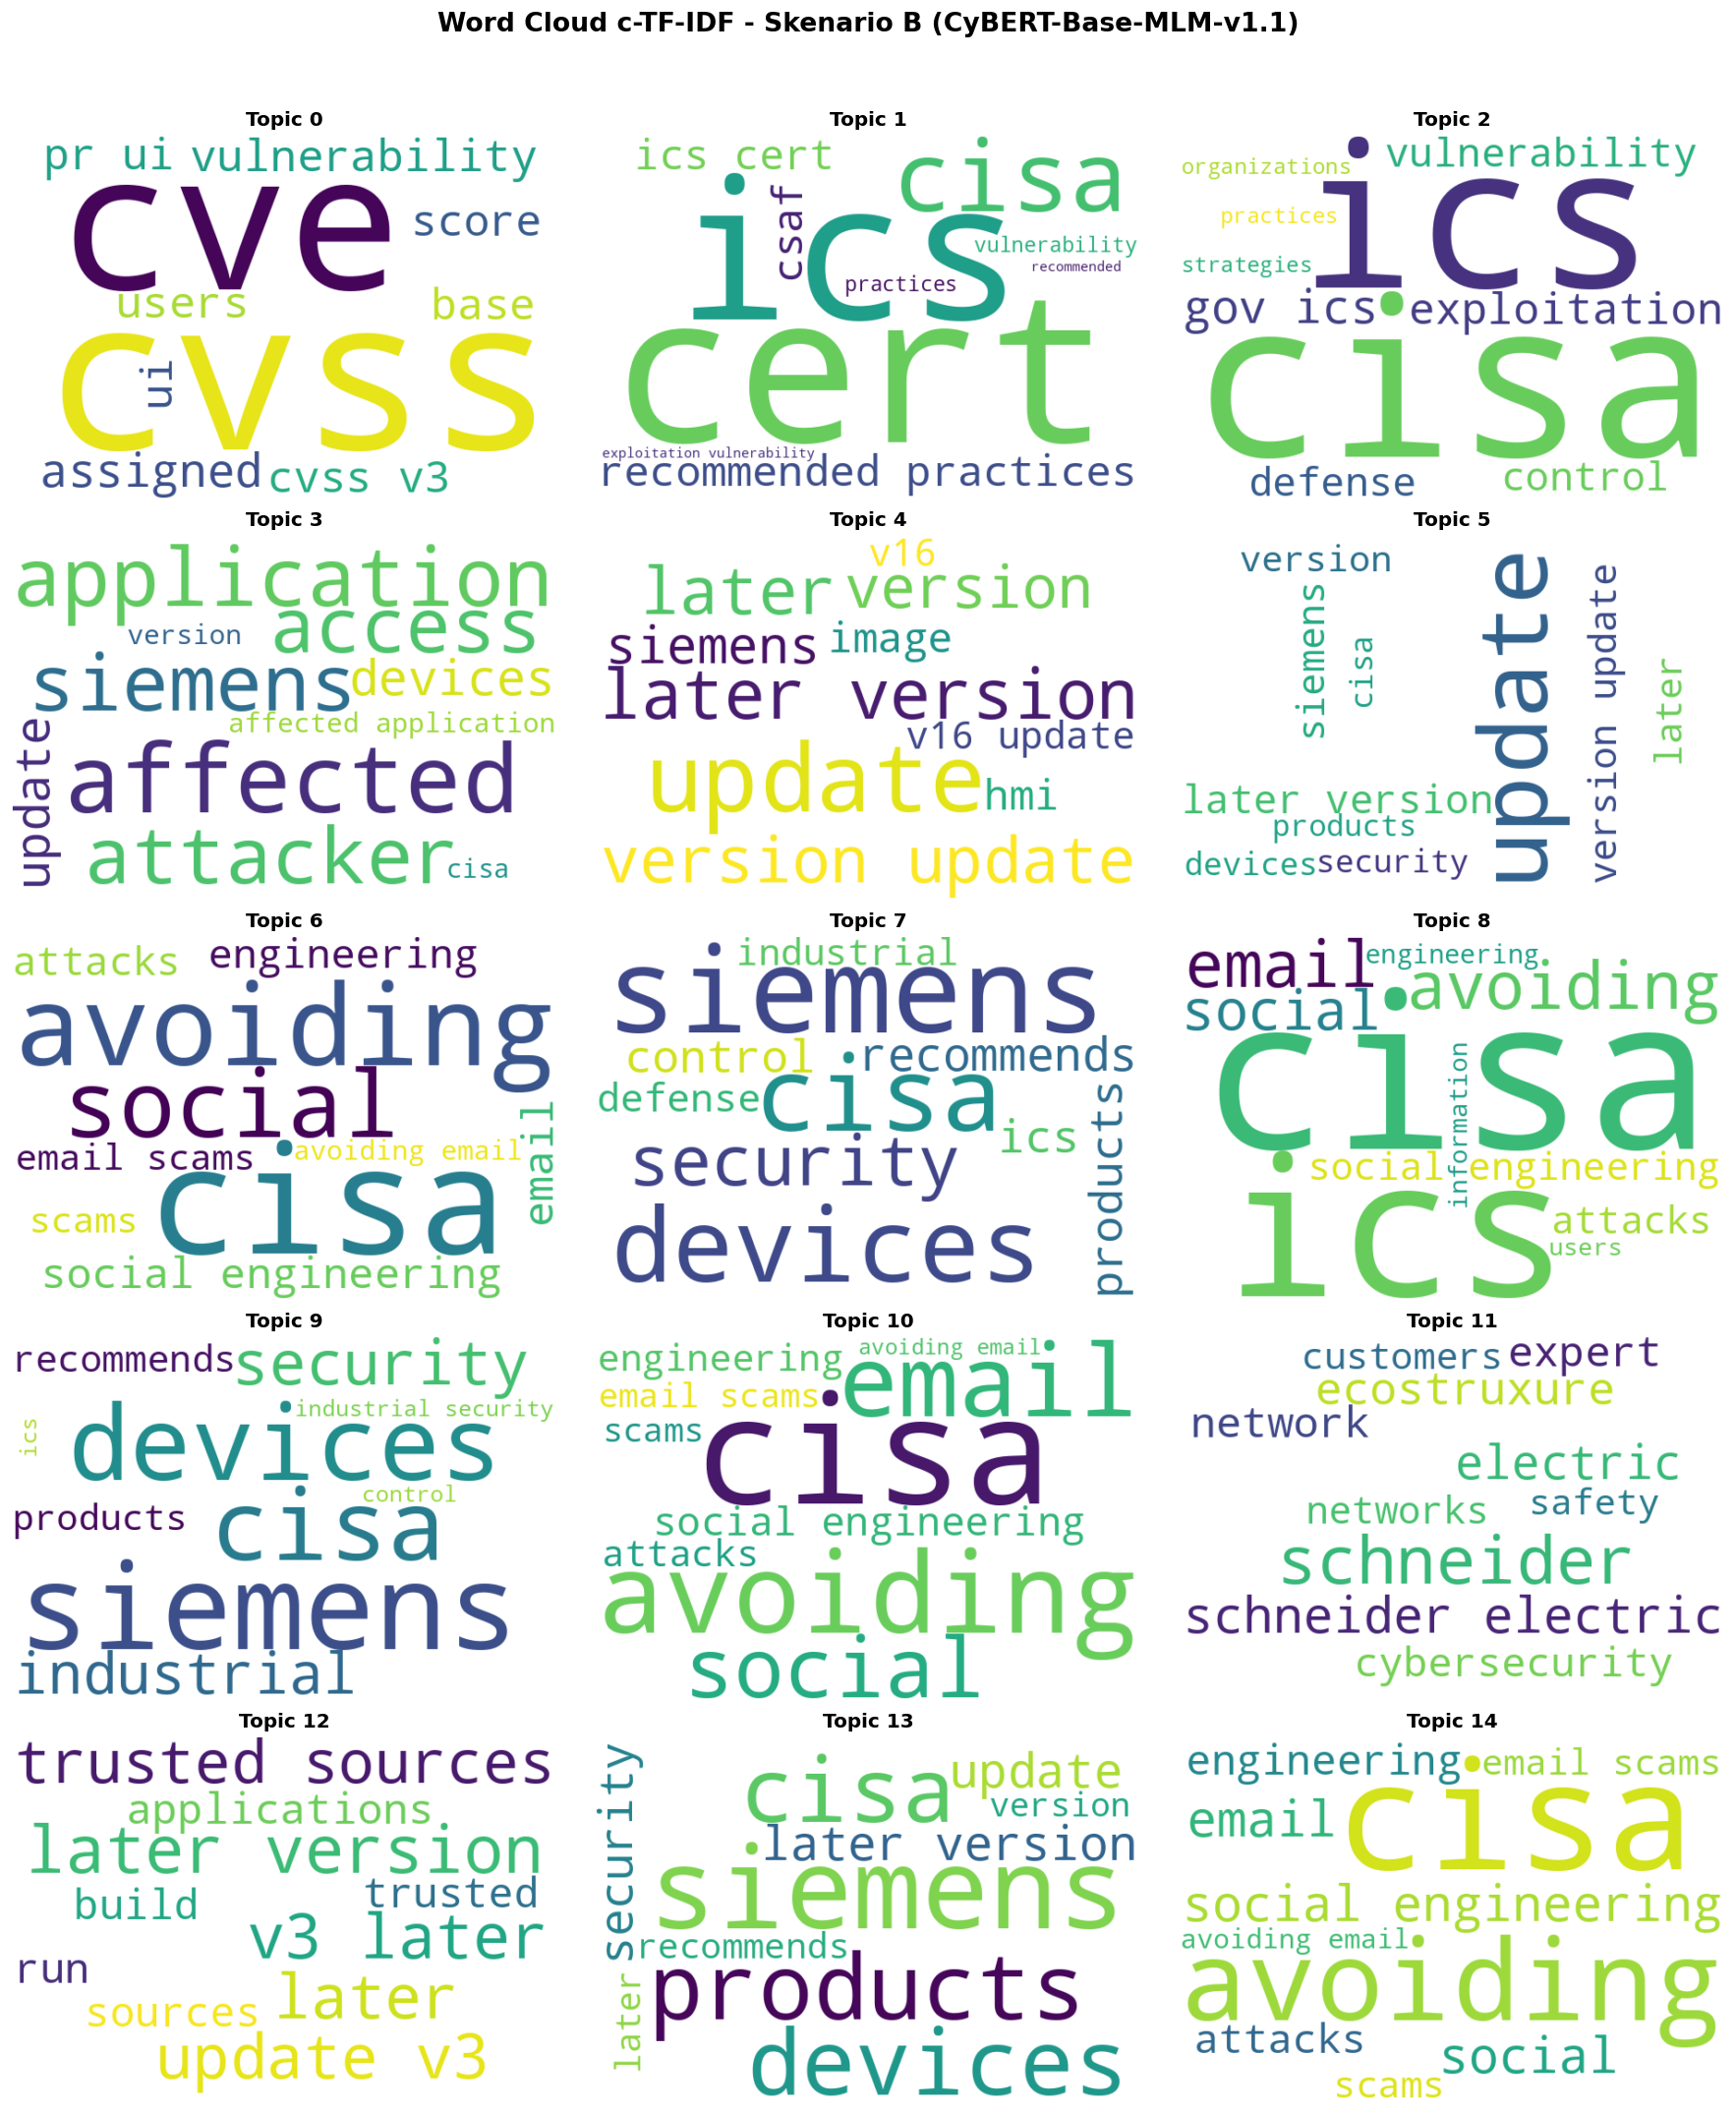

In [35]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import math

def plot_wordclouds_grid(topic_model, num_topics=15, title="Word Cloud Topik"):
    """
    Menghasilkan grid Word Cloud untuk n topik teratas berdasarkan model BERTopic.
    """
    # Mengambil ID topik valid (mengabaikan outlier -1)
    topic_info = topic_model.get_topic_info()
    valid_topics = topic_info[topic_info["Topic"] != -1]["Topic"].tolist()
    
    # Batasi jumlah topik yang divisualisasikan agar grid tidak terlalu padat
    topics_to_plot = valid_topics[:num_topics]
    n_topics = len(topics_to_plot)
    
    # Menentukan dimensi grid (misal: 3 kolom, baris menyesuaikan)
    cols = 3
    rows = math.ceil(n_topics / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3.5 * rows), sharex=True, sharey=True)
    axes = axes.flatten()

    for i, topic_id in enumerate(topics_to_plot):
        # Ekstrak kata dan skor c-TF-IDF dari BERTopic
        # get_topic mengembalikan list of tuples: [('kata1', 0.05), ('kata2', 0.04), ...]
        words_and_scores = topic_model.get_topic(topic_id)
        
        if not words_and_scores:
            axes[i].axis('off')
            continue
            
        # Konversi ke dictionary yang dibutuhkan oleh WordCloud
        frequencies = {word: score for word, score in words_and_scores}
        
        # Inisialisasi WordCloud (warna background disesuaikan dengan referensi paper)
        wc = WordCloud(
            width=600, 
            height=400, 
            background_color="white", 
            colormap="viridis", # Bisa diganti "tab20" atau "Blues" sesuai estetika
            max_words=20
        )
        wc.generate_from_frequencies(frequencies)
        
        # Render ke subplot
        axes[i].imshow(wc, interpolation="bilinear")
        axes[i].set_title(f"Topic {topic_id}", fontsize=12, fontweight="bold")
        axes[i].axis("off")
        
    # Sembunyikan subplot kosong jika num_topics bukan kelipatan cols
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(title, fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# Eksekusi untuk Skenario A (all-MiniLM-L6-v2)
# ---------------------------------------------------------
print("=== Word Cloud Skenario A (15 Topik Terbesar) ===")
plot_wordclouds_grid(topic_model_A, num_topics=15, title="Word Cloud c-TF-IDF - Skenario A (all-MiniLM-L6-v2)")

# ---------------------------------------------------------
# Eksekusi untuk Skenario B (CyBERT)
# ---------------------------------------------------------
print("=== Word Cloud Skenario B (15 Topik Terbesar) ===")
plot_wordclouds_grid(topic_model_B, num_topics=15, title="Word Cloud c-TF-IDF - Skenario B (CyBERT-Base-MLM-v1.1)")

In [36]:
# Skenario A
fig_hierarchy_A = topic_model_A.visualize_hierarchy(top_n_topics=20)
fig_hierarchy_A.write_html(RESULTS_A / "hierarchy_skenario_A.html")
fig_hierarchy_A.show()

# Skenario B
fig_hierarchy_B = topic_model_B.visualize_hierarchy(top_n_topics=20)
fig_hierarchy_B.write_html(RESULTS_B / "hierarchy_skenario_B.html")
fig_hierarchy_B.show()

In [37]:
# Skenario A
fig_heatmap_A = topic_model_A.visualize_heatmap(n_clusters=5, width=800, height=800)
fig_heatmap_A.write_html(RESULTS_A / "heatmap_skenario_A.html")
fig_heatmap_A.show()

# Skenario B
fig_heatmap_B = topic_model_B.visualize_heatmap(n_clusters=5, width=800, height=800)
fig_heatmap_B.write_html(RESULTS_B / "heatmap_skenario_B.html")
fig_heatmap_B.show()